# Customer Segmentation from the Betting Database

Pulls per-customer betting statistics from the MySQL `mathbet` database, then uses
the Elbow method + KMeans to segment customers into behavioural profiles
(High Roller, Risky Player, Low Stake, Casual Bettor) and exports the result to Excel.

**Setup:** set your DB password in the environment before running, e.g.
`export MYSQL_PASSWORD=yourpassword` (Linux/Mac) or `setx MYSQL_PASSWORD yourpassword` (Windows).

C:\Users\pante\AppData\Local\Temp\ipykernel_43976\1967160848.py:31: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, conn)
c:\Users\pante\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\pante\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(
c:\Users\pante\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory l

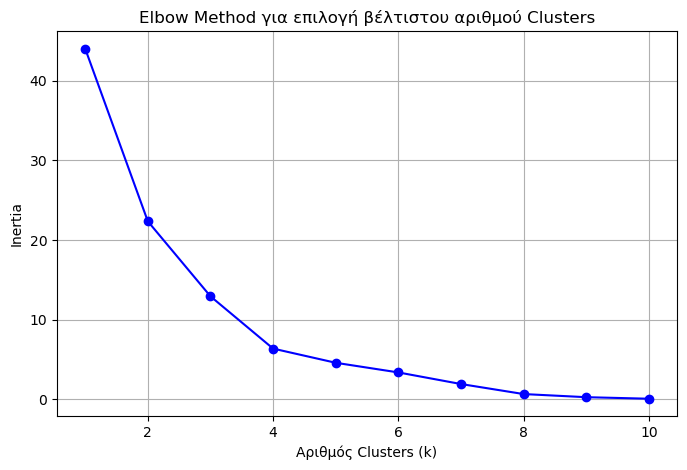

In [1]:
import os
import mysql.connector
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from dotenv import load_dotenv
load_dotenv()

conn = mysql.connector.connect(
    host='localhost',
    user=os.environ.get('MYSQL_USER', 'root'),
    password=os.environ.get('MYSQL_PASSWORD'),  # set MYSQL_PASSWORD in your environment
    database=os.environ.get('MYSQL_DB', 'mathbet'),
    charset='utf8mb4'
)

query = '''
SELECT 
    s.customers_id AS customer_id,
    COUNT(*) AS total_bets,
    SUM(s.amount) AS total_amount,
    AVG(s.amount) AS avg_bet_amount,
    MAX(s.amount) AS max_bet_amount,
    AVG(s.odds) AS avg_odds
FROM stoixhmata s
GROUP BY s.customers_id;
'''

df = pd.read_sql(query, conn)
conn.close()

features = df.drop('customer_id', axis=1)
scaler = StandardScaler()
features_scaled = scaler.fit_transform(features)

inertia = []
K = range(1, 11)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(features_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(K, inertia, 'bo-')
plt.xlabel('Αριθμός Clusters (k)')
plt.ylabel('Inertia')
plt.title('Elbow Method για επιλογή βέλτιστου αριθμού Clusters')
plt.grid(True)
plt.show()




Μέσοι όροι ανά Cluster:
         total_bets  total_amount  avg_bet_amount  max_bet_amount  avg_odds
cluster                                                                    
0               1.0        587.25          587.25          587.25    1.4525
1               1.0        742.50          742.50          742.50    2.2925
2               1.0       2000.00         2000.00         2000.00    1.1500
3               1.0         32.50           32.50           32.50    2.1000


c:\Users\pante\anaconda3\Lib\site-packages\sklearn\cluster\_kmeans.py:1419: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=1.
  warnings.warn(


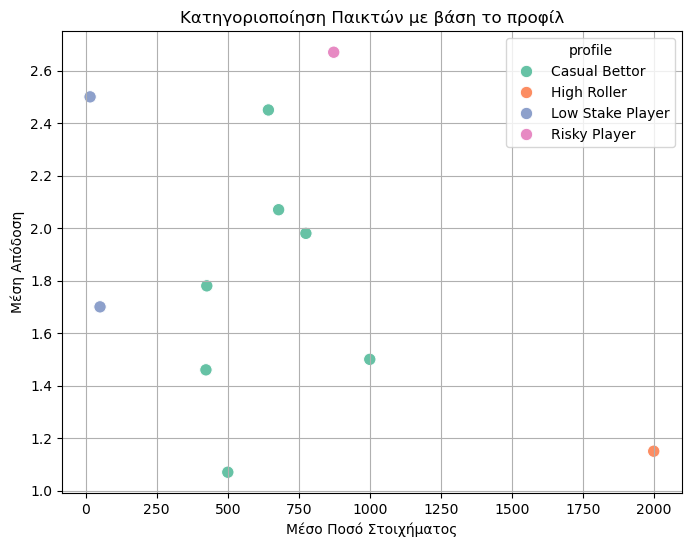

   customer_id           profile
0            1     Casual Bettor
1            2       High Roller
2            3  Low Stake Player
3            4  Low Stake Player
4            5     Casual Bettor


In [2]:
kmeans = KMeans(n_clusters=4, random_state=42)
df['cluster'] = kmeans.fit_predict(features_scaled)

cluster_summary = df.groupby('cluster')[['total_bets', 'total_amount', 'avg_bet_amount', 'max_bet_amount', 'avg_odds']].mean()
print("\nΜέσοι όροι ανά Cluster:")
print(cluster_summary)


def assign_profile(row):
    if row['avg_bet_amount'] > 1000:
        return "High Roller"
    elif row['avg_bet_amount'] > 700 and row['avg_odds'] > 2.4:
        return "Risky Player"
    elif row['avg_bet_amount'] < 100:
        return "Low Stake Player"
    else:
        return "Casual Bettor"

df['profile'] = df.apply(assign_profile, axis=1)

plt.figure(figsize=(8, 6))
sns.scatterplot(data=df, x='avg_bet_amount', y='avg_odds', hue='profile', palette='Set2',s=80)
plt.title("Κατηγοριοποίηση Παικτών με βάση το προφίλ")
plt.xlabel("Μέσο Ποσό Στοιχήματος")
plt.ylabel("Μέση Απόδοση")
plt.grid(True)
plt.show()

print(df[['customer_id', 'profile']].head())

df[['customer_id', 'profile']].to_excel("player_profiles.xlsx", index=False)
